# Notebook 1.5 — Which edit method should you use?

A controlled comparison of **three** ways to insert a rare edge-case into a real photo.

| Method | Inputs to the generator | Typical failure mode |
|--------|-------------------------|----------------------|
| **Inpaint + mask** | RGB + binary hole + prompt | Needs a good mask; edges can show |
| **ControlNet depth + seg (no mask)** | RGB + depth map + seg map + prompt | Can rewrite the whole scene |
| **Instruction edit** | RGB + text instruction only | Weak spatial control; may ignore the ask |

**Seeds:** 3 clean `scene_*` Mapillary frames (no target anomaly yet).  
**Inserts:** workshop set from config — `road_debris`, `traffic_cone`, `fog` (one per image).

Tagged `traffic_cone_*` / `road_debris_*` / etc. frames are real positives for later detector eval — **not** used as edit seeds here.

Set `HARDWARE = "cpu"` or `"gpu_l4"` below — model IDs come from `configs/hardware/*.yaml`.

> Notebook 1 will later become the thin “pick a method → generate → judge” path. This notebook is the deep dive.


---
## 0. Setup


In [3]:
import sys
from pathlib import Path

def _find_project_root() -> Path:
    """Locate edge_case_image_generation root (has src/edgecase_synthesis + configs)."""
    here = Path.cwd().resolve()
    search = [here, *here.parents]
    # Common Cursor/Jupyter cwd: monorepo root — look one level down.
    for base in list(search):
        nested = base / "implementations" / "edge_case_image_generation"
        if nested.is_dir():
            search.append(nested)
    for base in search:
        if (base / "src" / "edgecase_synthesis").is_dir() and (base / "configs").is_dir():
            return base
        if base.name == "notebooks" and (base.parent / "src" / "edgecase_synthesis").is_dir():
            return base.parent
    raise FileNotFoundError(
        "Could not find edge_case_image_generation project root.\n"
        f"cwd={here}\n"
        "Open notebooks from implementations/edge_case_image_generation/notebooks/ "
        "and select the EdgeCase Synthesis kernel (.venv)."
    )

PROJECT_ROOT = _find_project_root()
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
print("Project root:", PROJECT_ROOT)
import edgecase_synthesis
print("Package:", edgecase_synthesis.__version__)


Project root: /Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/implementations/edge_case_image_generation
Package: 0.1.0


---
## 1. Load config + 3 clean scene images

Use `scene_*` frames as **empty road seeds**. Each gets a different anomaly inserted.


DataSourceInfo(name='mapillary_vistas', label='Mapillary Vistas v2 (toy street subset)', license='CC BY-NC-SA 4.0', attribution='Mapillary Vistas Dataset v2.0 (Neuhold et al.). HF mirror: https://huggingface.co/datasets/candylion/mapillary-vistas-v2')
family= sd15 device hint= None
inpaint= runwayml/stable-diffusion-inpainting
instruct= timbrooks/instruct-pix2pix
controlnets= {'depth': 'lllyasviel/sd-controlnet-depth', 'seg': 'lllyasviel/sd-controlnet-seg'}
Edit plan (clean seed → insert anomaly):
  scene_L0bY5HKnbiU8hi5pYQg7hQ  →  synthesize pothole
  scene_LelW-zoLMtcodvv51foZXw  →  synthesize traffic_cone
  scene_TcVl0UUi5lGGn4H7h2RC5g  →  synthesize ground_animal


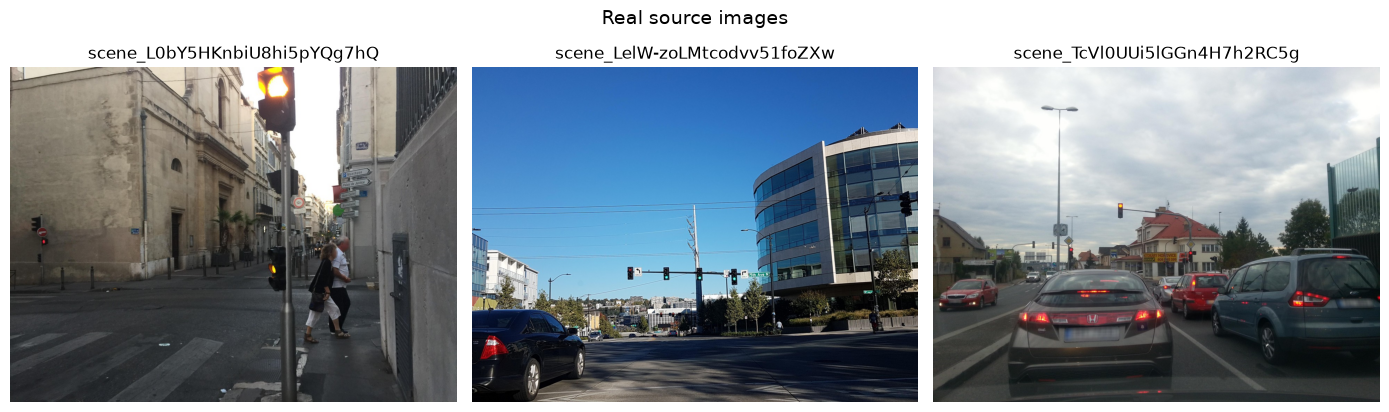

In [4]:
import os

# HF Xet downloads of large FLUX weights often fail with
# "Background writer channel closed" (disk/I/O masked). Prefer classic HTTP.
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

from edgecase_synthesis.config import load_config, load_anomaly
from edgecase_synthesis.data import (
    get_data_source_info,
    list_sample_images,
    load_sample_images,
    prepare_sample_images,
    ImageSample,
)
from edgecase_synthesis.viz import show_samples
from PIL import Image

HARDWARE = "cpu"  # or "gpu_l4"
cfg = load_config(start=PROJECT_ROOT, overrides=[f"hardware={HARDWARE}"])
info = get_data_source_info(cfg)
print(info)
print("family=", cfg.generation.family, "device hint=", cfg.hardware.device)
print("inpaint=", cfg.generation.inpaint_model_id)
print("instruct=", cfg.generation.instruct_model_id)
print("controlnets=", dict(cfg.generation.controlnet))

prepare_sample_images(cfg=cfg)
samples_dir = Path(cfg.paths.samples_dir)

# Clean seeds only — frames that do NOT already contain the rare class.
# Stick to configs/generation/default.yaml → workshop_anomalies.
ANOMALIES = list(cfg.generation.get("workshop_anomalies") or ["road_debris", "traffic_cone", "fog"])
scene_paths = sorted(p for p in list_sample_images(samples_dir) if p.stem.startswith("scene_"))
if len(scene_paths) < len(ANOMALIES):
    raise RuntimeError(
        f"Need ≥{len(ANOMALIES)} scene_* images, found {len(scene_paths)}. "
        "Re-run scripts/extract_mapillary_toy.py"
    )

jobs = []
for path, anomaly_id in zip(scene_paths[: len(ANOMALIES)], ANOMALIES):
    sample = ImageSample(path=path, image=Image.open(path).convert("RGB"), name=path.stem)
    jobs.append((sample, anomaly_id))

samples = [s for s, _ in jobs]
show_samples(samples, ncol=3, figsize=(14, 4))
print("Edit plan (clean seed → insert anomaly):")
for s, a in jobs:
    print(f"  {s.name}  →  synthesize {a}")


---
## 2. Structure maps (used by methods 1 & 2 only)

- **Depth** — near/far geometry (ControlNet condition; also `prefer_near` for the inpaint mask)
- **Segmentation** — ADE “road” support for the inpaint mask; colored map → ControlNet-seg (CPU) or Canny-on-seg (L4)

Method 3 (**instruct**) ignores both.


Loading weights:   0%|          | 0/287 [00:00<?, ?it/s]

depth: depth-anything/Depth-Anything-V2-Base-hf on mps
seg:   nvidia/segformer-b2-finetuned-ade-512-512 on mps


Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

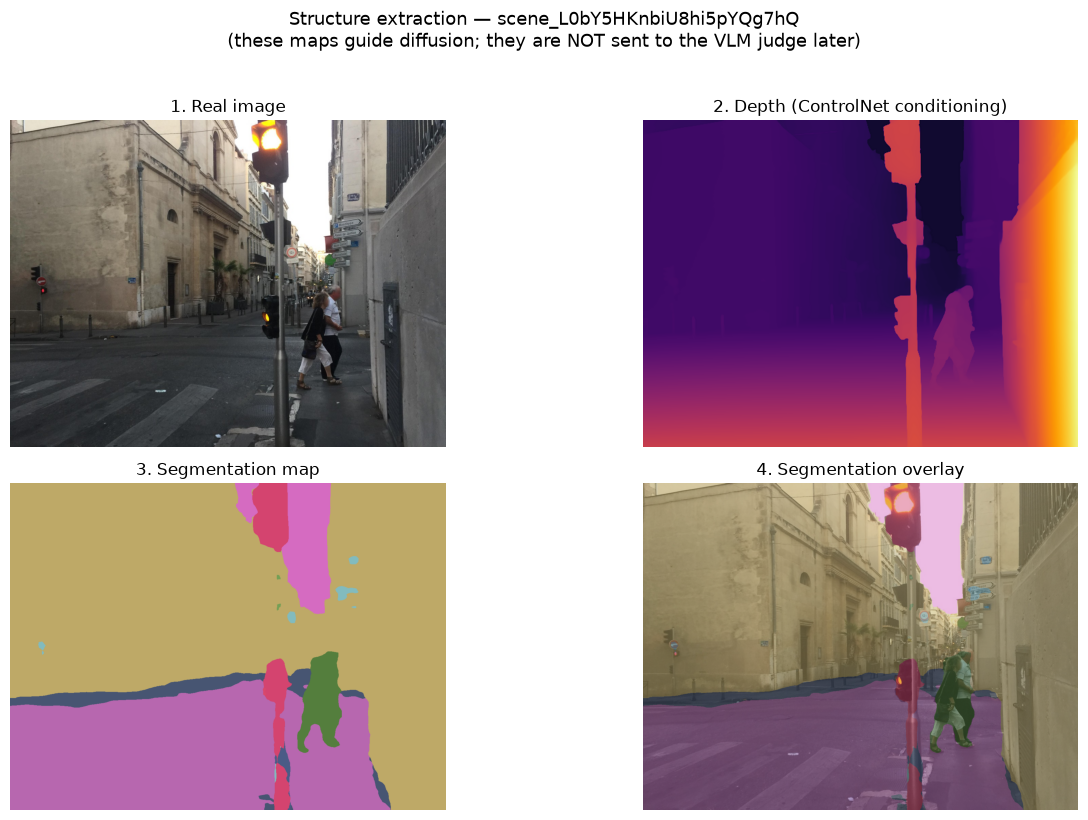

In [5]:
from edgecase_synthesis.conditioning import DepthEstimator, Segmenter
from edgecase_synthesis.viz import show_depth_result, show_segmentation_result, show_structure_overview

depth_model = DepthEstimator.from_config(cfg)
segmenter = Segmenter.from_config(cfg)
print("depth:", depth_model.model_id, "on", depth_model.device)
print("seg:  ", segmenter.model_name, "on", segmenter.device)

depth_results = {}
seg_results = {}
for sample in samples:
    depth_results[sample.name] = depth_model.predict(sample.image)
    seg_results[sample.name] = segmenter.predict(sample.image)

# Show intermediate maps for the first job
show_structure_overview(samples[0], depth_results[samples[0].name], seg_results[samples[0].name]);


---
## 3. What each method consumes

Read this once — it is the pedagogical core of the notebook.


In [6]:
from edgecase_synthesis.compare_methods import METHOD_SPECS, COMPARE_METHODS

for key in COMPARE_METHODS:
    spec = METHOD_SPECS[key]
    print(f"=== {spec.title} ({key}) ===")
    print(f"  mask={spec.uses_mask}  depth={spec.uses_depth}  seg={spec.uses_seg}")
    print(f"  {spec.summary}")
    print()


=== Inpaint + mask (inpaint) ===
  mask=True  depth=True  seg=True
  Edit only inside a mask (ellipse ∩ road ∩ near). Best for local inserts.

=== ControlNet depth + seg (no mask) (controlnet_dual) ===
  mask=False  depth=True  seg=True
  Full-frame img2img guided by depth and segmentation maps. No hole mask.

=== Instruction edit (image + prompt) (instruct) ===
  mask=False  depth=False  seg=False
  InstructPix2Pix-style editor: only RGB + text instruction. No structure maps.



---
## 4. Run all 3 methods × 3 images

First run downloads extra weights (seg ControlNet; InstructPix2Pix on CPU, or FLUX.2-klein-4B on L4). On CPU this is slow — that is expected for the study.


In [ ]:
from edgecase_synthesis.compare_methods import MethodComparer
from edgecase_synthesis.viz import show_method_comparison, save_compare_artifacts

comparer = MethodComparer.from_config(cfg)
print("comparer device=", comparer.device, "family=", comparer.family)
print("seg ControlNet=", comparer.seg_controlnet_id, "seg_as_canny=", comparer.seg_as_canny)

dataset = str(cfg.generation.anomaly_dataset)
bundles = []
output_dir = Path(cfg.paths.outputs_dir)

for sample, anomaly_id in jobs:
    print(f"\n### {sample.name} / {anomaly_id}")
    anomaly_cfg = load_anomaly(dataset, anomaly_id, start=PROJECT_ROOT)
    bundle = comparer.compare_one(
        sample.image,
        sample_name=sample.name,
        depth=depth_results[sample.name],
        segmentation=seg_results[sample.name],
        generation_cfg=cfg.generation,
        anomaly_cfg=anomaly_cfg,
    )
    bundles.append((sample, bundle))
    show_method_comparison(sample, bundle)
    paths = save_compare_artifacts(sample, bundle, output_dir)
    print("saved →", paths["dir"])


comparer device= mps family= sd15
seg ControlNet= lllyasviel/sd-controlnet-seg seg_as_canny= False

### scene_L0bY5HKnbiU8hi5pYQg7hQ / pothole
  → inpaint …


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.
/Users/arvinazarmina/Documents/Projects/SynthesysBootCamp/EdgeCaseSynthesis/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

...

  → controlnet_dual …


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet_img2img.StableDiffusionControlNetImg2ImgPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


  0%|          | 0/17 [00:00<?, ?it/s]

---
## 5. Side-by-side recap grid

One row per image: original + the three outputs.


In [ ]:
import matplotlib.pyplot as plt
from edgecase_synthesis.compare_methods import COMPARE_METHODS, METHOD_SPECS
from edgecase_synthesis.viz import show_image

fig, axes = plt.subplots(len(bundles), 4, figsize=(16, 4 * len(bundles)))
if len(bundles) == 1:
    axes = axes.reshape(1, -1)

for row, (sample, bundle) in enumerate(bundles):
    show_image(sample.image, title=f"{bundle.anomaly_id}\noriginal", ax=axes[row, 0])
    for col, method in enumerate(COMPARE_METHODS, start=1):
        result = bundle.results[method]
        show_image(result.image, title=METHOD_SPECS[method].title, ax=axes[row, col])

fig.suptitle(f"Method comparison summary (hardware={HARDWARE})", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(Path(cfg.paths.outputs_dir) / "compare" / f"summary_{HARDWARE}.png", dpi=140, bbox_inches="tight")
print("summary saved")


---
## 6. How to read the results (discussion prompts)

Use these questions in the bootcamp:

1. **Spatial control** — Which method actually put the object *on the road* where you wanted?
2. **Scene preservation** — Which method kept cars / sky / trees intact?
3. **Mask cost** — Inpaint needs a mask (here: ellipse ∩ seg-road ∩ near-depth). Is that worth it?
4. **Full-frame ControlNet** — Did depth+seg stop the model from drifting, or did it still rewrite too much?
5. **Instruction-only** — Did the instruct model (Klein on L4 / InstructPix2Pix on CPU) follow the ask, or change style / ignore placement?

**Rule of thumb for this bootcamp**

- Need a **local insert** (cone, cardboard debris on asphalt) → start with **inpaint + mask**
- Need **global atmosphere** (fog) while keeping layout → try **ControlNet** or **instruct**
- Need a **prompt-only baseline** / ablation → **instruct**

Pick a winner for your domain, then Notebook 1 can call that method only.


---
## Wrap-up

Artifacts: `outputs/compare/<sample>_<anomaly>/` plus `outputs/compare/summary_{hardware}.png`.

Next:

1. Re-run with `HARDWARE = "gpu_l4"` and compare quality / speed
2. Notebook 1 — thin pipeline that plugs in the method you choose here
3. Notebook 2 — batch + VLM retry loop on the chosen method
